In [1]:

import os
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/Roopa-Analytics/CHD-risk-Prediction/main/Data/framingham.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:

# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [5]:
# Check missing values in each column
print(df.isnull().sum())

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


In [6]:
# Calculate missing values and percentages
missing = pd.DataFrame({
    "Missing count": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(1)
})

print(missing)

                 Missing count  Missing (%)
male                         0          0.0
age                          0          0.0
education                  105          2.5
currentSmoker                0          0.0
cigsPerDay                  29          0.7
BPMeds                      53          1.2
prevalentStroke              0          0.0
prevalentHyp                 0          0.0
diabetes                     0          0.0
totChol                     50          1.2
sysBP                        0          0.0
diaBP                        0          0.0
BMI                         19          0.4
heartRate                    1          0.0
glucose                    388          9.2
TenYearCHD                   0          0.0


In [7]:
# Drop the education column
df = df.drop(columns=["education"])

# Check the updated dataset
print("Dataset shape after dropping education:", df.shape)
print(df.head())

Dataset shape after dropping education: (4240, 15)
   male  age  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39              0         0.0     0.0                0   
1     0   46              0         0.0     0.0                0   
2     1   48              1        20.0     0.0                0   
3     0   61              1        30.0     0.0                0   
4     0   46              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0           0  
1           0  
2           0  
3

In [8]:
# Select numerical columns
num_cols = df.select_dtypes(include=["number"]).columns

# Count outliers using the IQR method
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

male: 0 outliers
age: 0 outliers
currentSmoker: 0 outliers
cigsPerDay: 12 outliers
BPMeds: 124 outliers
prevalentStroke: 25 outliers
prevalentHyp: 0 outliers
diabetes: 109 outliers
totChol: 56 outliers
sysBP: 126 outliers
diaBP: 77 outliers
BMI: 97 outliers
heartRate: 76 outliers
glucose: 188 outliers
TenYearCHD: 644 outliers


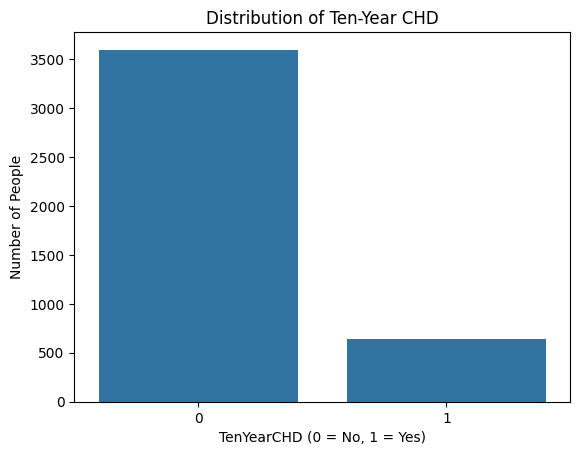

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot target variable distribution
sns.countplot(data=df, x="TenYearCHD")

plt.title("Distribution of Ten-Year CHD")
plt.xlabel("TenYearCHD (0 = No, 1 = Yes)")
plt.ylabel("Number of People")
plt.show()

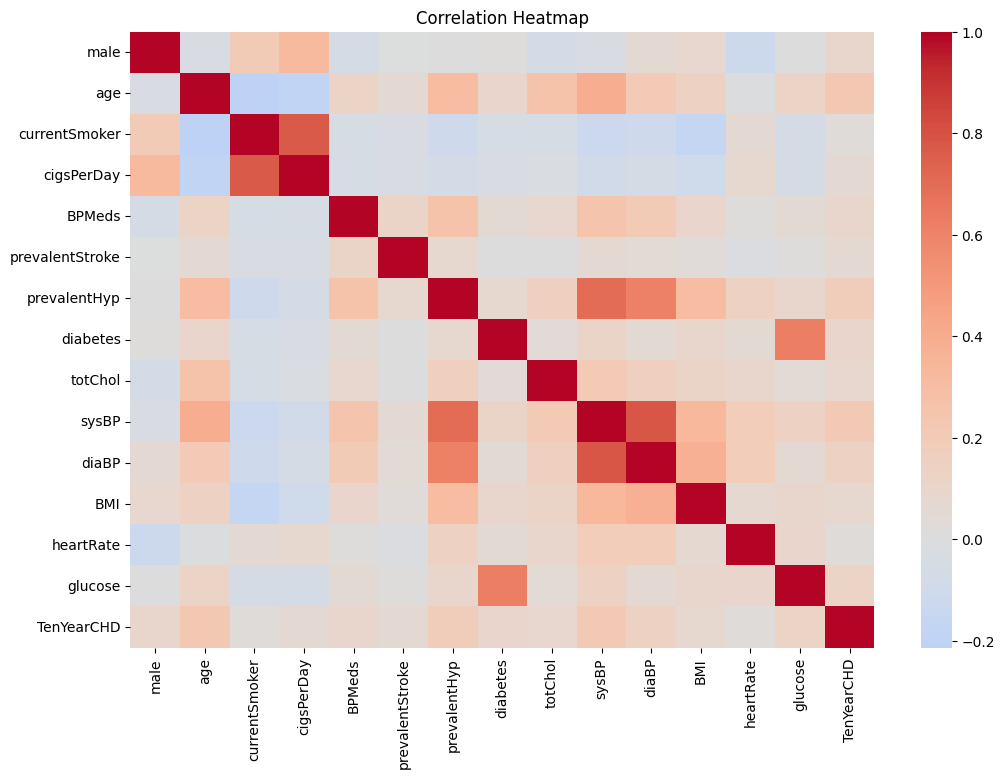

In [10]:
# Calculate correlation between numerical columns
correlation = df.corr(numeric_only=True)

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [11]:
# Select input features
feature_cols = [
    'male', 'age', 'currentSmoker', 'cigsPerDay', 'BPMeds',
    'prevalentStroke', 'prevalentHyp', 'diabetes',
    'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose'
]

X = df[feature_cols]

# Select target variable
y = df['TenYearCHD']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4240, 14)
Target shape: (4240,)


In [12]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (3180, 14)
Testing features: (1060, 14)
Training target: (3180,)
Testing target: (1060,)


In [13]:
# Make copies of the training and testing data
X_train = X_train.copy()
X_test = X_test.copy()

# Fill missing values in numerical columns using training medians
num_cols = ['cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']

for col in num_cols:
    med = X_train[col].median()
    X_train[col] = X_train[col].fillna(med)
    X_test[col] = X_test[col].fillna(med)

# Fill missing BPMeds values using the training mode
bp_mode = X_train['BPMeds'].mode()[0]

X_train['BPMeds'] = X_train['BPMeds'].fillna(bp_mode)
X_test['BPMeds'] = X_test['BPMeds'].fillna(bp_mode)

# Check remaining missing values
print(
    "Missing after preprocessing (train, test):",
    X_train.isnull().sum().sum(),
    X_test.isnull().sum().sum()
)

Missing after preprocessing (train, test): 0 0


In [14]:
# Check missing values in training and testing sets
print("Training set missing values:")
print(X_train.isnull().sum())

print("\nTesting set missing values:")
print(X_test.isnull().sum())

# Check target distribution
print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set missing values:
male               0
age                0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
dtype: int64

Testing set missing values:
male               0
age                0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
dtype: int64

Training target distribution:
TenYearCHD
0    2697
1     483
Name: count, dtype: int64

Testing target distribution:
TenYearCHD
0    899
1    161
Name: count, dtype: int64
